# Crete title-page density zoom

Apocentre, inner flow, and nozzle.

In [1]:
%load_ext autoreload
%autoreload 2

import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-rich-tde-crete")

from pathlib import Path
import math

import dev  # repository plotting style; import before pyplot
import matplotlib.pyplot as plt
from matplotlib.patches import ConnectionPatch, Rectangle
import matplotlib.patheffects as pe
import numpy as np

import richio
from dev.datapaths import DATAPATHS, SNAPSHOT_TFB, TDE_PARAMETERS

## Snapshot, nested boxes, and output settings

Production defaults; environment variables can override them.

In [2]:
RUN = os.environ.get("CRETE_RUN", "1e4")
if RUN in {"1e4", "1e5"}:
    snapnums, snapshots = DATAPATHS(RUN)
    SNAPNUM, SNAPSHOT = snapnums[-1], Path(snapshots[-1])
elif RUN == "1e6":
    SNAPNUM, SNAPSHOT = SNAPSHOT_TFB(RUN, 1.0)
    SNAPSHOT = Path(SNAPSHOT)
else:
    raise ValueError(f"unsupported run: {RUN}")

M_BH, M_STAR, R_STAR = TDE_PARAMETERS[RUN]
R_T = R_STAR * (M_BH / M_STAR) ** (1 / 3)
R_A = R_T**2 / R_STAR

if RUN == "1e4":
    INNER_X = np.array([-2.0, 1.0]) * R_A
    INNER_Y = 1.5 * R_A
else:
    reference_ra = 0.47 * (1e4 / 0.5) ** (2 / 3)
    INNER_X = np.array([-500.0, 300.0]) / reference_ra * R_A
    INNER_Y = 400.0 / reference_ra * R_A

Z_HALF = 4.25 * R_A
BOXES = {
    "apocentre": np.array([-6.0 * R_A, -4.25 * R_A, -Z_HALF,
                                2.5 * R_A,  4.25 * R_A,  Z_HALF]),
    "inner flow": np.array([INNER_X[0], -INNER_Y, -Z_HALF,
                                  INNER_X[1],  INNER_Y,  Z_HALF]),
    "nozzle": np.array([-2.0 * R_T, -2.0 * R_T, -Z_HALF,
                               2.0 * R_T,  2.0 * R_T,  Z_HALF]),
}

NXY = int(os.environ.get("CRETE_NXY", "1024"))
NZ = int(os.environ.get("CRETE_NZ", "256"))
DPI = int(os.environ.get("CRETE_DPI", "300"))
WORKERS = int(os.environ.get("CRETE_WORKERS", "16"))
RECOMPUTE = os.environ.get("CRETE_RECOMPUTE", "0") == "1"

OUTPUT_DIR = Path("/home/hey4/rich_tde/data/processed/CreteCover") / RUN
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE = OUTPUT_DIR / f"snap-{SNAPNUM:04d}-density-zoom-{NXY}x{NXY}x{NZ}.npz"
FIGURE_STEM = (f"crete-title-density-zoom-{RUN}" if NXY >= 700
               else f"crete-title-density-zoom-{RUN}-preview-{NXY}")

print(f"snapshot: {SNAPSHOT}")
print(f"r_t={R_T:.3f} R_sun, r_a={R_A:.3f} R_sun")
print(f"projection: {NXY} x {NXY} pixels, {NZ} z intervals; output: {DPI} dpi")

snapshot: /data1/projects/pi-rossiem/TDE_data/NewSnellius/R0.47M0.5BH10000beta1S60ComptonHiRes/snap_full_151.h5
r_t=12.758 R_sun, r_a=346.299 R_sun
projection: 1024 x 1024 pixels, 256 z intervals; output: 300 dpi


## Compute or load the three projections

Cached face-on column-density maps.

In [3]:
def transverse_selection(x, y, box, pad_fraction=0.10):
    dx, dy = box[3] - box[0], box[4] - box[1]
    unit = richio.units.lscale
    return (
        (x >= (box[0] - pad_fraction * dx) * unit)
        & (x <= (box[3] + pad_fraction * dx) * unit)
        & (y >= (box[1] - pad_fraction * dy) * unit)
        & (y <= (box[4] + pad_fraction * dy) * unit)
    )


def compute_projections():
    snap = richio.load(str(SNAPSHOT))
    x, y, z, density = snap.CMx, snap.CMy, snap.CMz, snap.density
    result = {}
    for name, box in BOXES.items():
        selection = transverse_selection(x, y, box)
        print(f"{name:10s}: {selection.sum():,} selected source cells", flush=True)
        sigma, x_edges, y_edges = snap.project(
            density,
            X=x, Y=y, Z=z,
            res=(NXY + 1, NXY + 1, NZ + 1),
            box_size=box,
            selection=selection,
            unit_system="cgs",
            workers=WORKERS,
            spacing=("linear", "linear", "sinh"),
            sinh_scale=(None, None, 0.1 * richio.units.lscale),
        )
        result[name] = {
            "sigma": np.asarray(sigma, dtype=np.float64),
            "x": np.asarray(x_edges / richio.units.lscale, dtype=np.float64),
            "y": np.asarray(y_edges / richio.units.lscale, dtype=np.float64),
        }
    return snap, result


if CACHE.exists() and not RECOMPUTE:
    cached = np.load(CACHE)
    projections = {
        name: {key: cached[f"{name}_{key}"] for key in ("sigma", "x", "y")}
        for name in BOXES
    }
    snap = richio.load(str(SNAPSHOT))
    print(f"loaded {CACHE}")
else:
    snap, projections = compute_projections()
    np.savez(
        CACHE,
        **{f"{name}_{key}": value
           for name, panel in projections.items() for key, value in panel.items()},
    )
    print(f"saved {CACHE}")

T_FB = math.pi / math.sqrt(2) * math.sqrt(R_STAR**3 / M_STAR) * math.sqrt(M_BH / M_STAR)
TIME = float(np.asarray(snap.t).reshape(-1)[0])
print(f"snap {SNAPNUM}: t/t_fb={TIME / T_FB:.3f}")

apocentre : 70,235,563 selected source cells


inner flow: 60,461,379 selected source cells


nozzle    : 12,601,475 selected source cells


saved /home/hey4/rich_tde/data/processed/CreteCover/1e4/snap-0151-density-zoom-1024x1024x256.npz
snap 151: t/t_fb=2.175


## Cover figure

Global six-decade color scale.

global range: [1.0, 7.0]


saved /home/hey4/rich_tde/data/processed/CreteCover/1e4/crete-title-density-zoom-1e4.png
saved /home/hey4/rich_tde/data/processed/CreteCover/1e4/crete-title-density-zoom-1e4.pdf


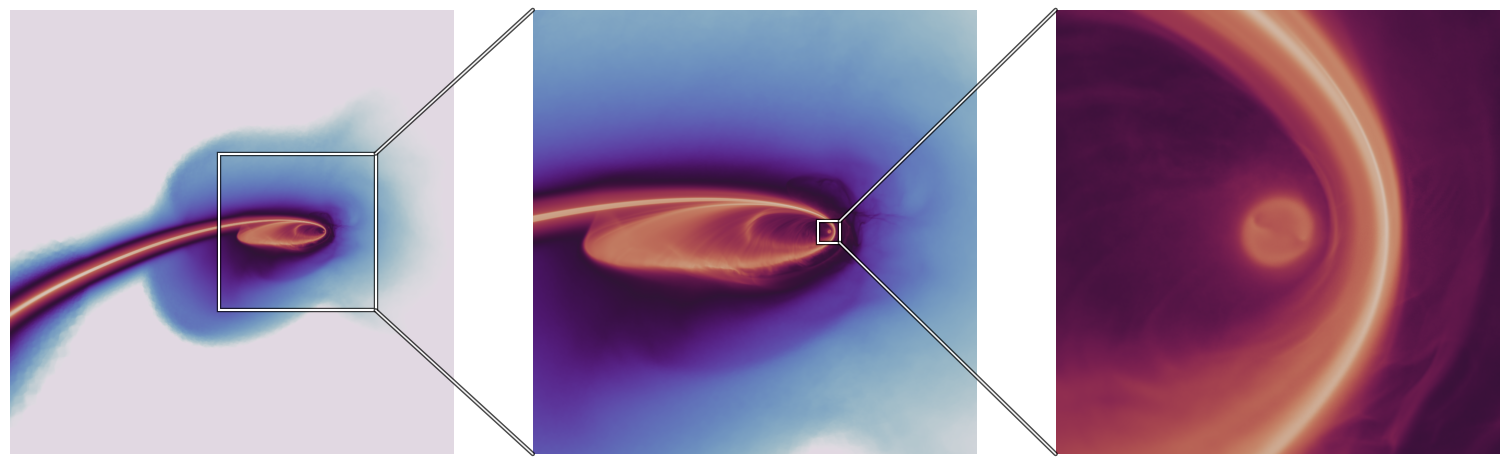

In [4]:
def log_surface_density(values):
    values = np.asarray(values, dtype=np.float64)
    return np.log10(np.where(values > 0, values, np.nan))


logs = {name: log_surface_density(panel["sigma"])
        for name, panel in projections.items()}
finite = np.concatenate([values[np.isfinite(values)] for values in logs.values()])
VMAX = math.ceil(float(np.nanpercentile(finite, 99.995)) * 2) / 2
VMIN = VMAX - 6.0
print(f"global range: [{VMIN:.1f}, {VMAX:.1f}]")

cmap = plt.get_cmap("twilight").copy()  # richio default
cmap.set_bad((0, 0, 0, 0))

line_effect = [pe.Stroke(linewidth=3.2, foreground="black", alpha=0.72), pe.Normal()]

def add_zoom(fig, source_ax, target_ax, target_box):
    x0, y0, _, x1, y1, _ = target_box
    rectangle = Rectangle(
        (x0, y0), x1 - x0, y1 - y0,
        fill=False, edgecolor="white", linewidth=1.45, zorder=8,
    )
    rectangle.set_path_effects(line_effect)
    source_ax.add_patch(rectangle)
    for source_point, target_point in (((x1, y1), (0, 1)), ((x1, y0), (0, 0))):
        connector = ConnectionPatch(
            xyA=source_point, coordsA=source_ax.transData,
            xyB=target_point, coordsB=target_ax.transAxes,
            color="white", linewidth=1.15, alpha=0.95,
            clip_on=False, zorder=7,
        )
        connector.set_path_effects(line_effect)
        fig.add_artist(connector)


fig, axes = plt.subplots(1, 3, figsize=(15.6, 4.55), facecolor="none")
fig.subplots_adjust(left=0.006, right=0.994, bottom=0.012, top=0.988, wspace=0.055)
for ax, (name, box) in zip(axes, BOXES.items()):
    panel = projections[name]
    ax.imshow(
        logs[name].T, origin="lower",
        extent=(panel["x"][0], panel["x"][-1],
                panel["y"][0], panel["y"][-1]),
        cmap=cmap, vmin=VMIN, vmax=VMAX,
        interpolation="bilinear", rasterized=True,
    )
    ax.set_xlim(box[0], box[3])
    ax.set_ylim(box[1], box[4])
    ax.set_aspect("equal")
    ax.set_axis_off()

add_zoom(fig, axes[0], axes[1], BOXES["inner flow"])
add_zoom(fig, axes[1], axes[2], BOXES["nozzle"])
png = OUTPUT_DIR / f"{FIGURE_STEM}.png"
pdf = OUTPUT_DIR / f"{FIGURE_STEM}.pdf"
fig.savefig(png, dpi=DPI, transparent=True, pad_inches=0)
fig.savefig(pdf, dpi=DPI, transparent=True, pad_inches=0)
print(f"saved {png}")
print(f"saved {pdf}")
plt.show()

In [5]:
from PIL import Image

with Image.open(png) as image:
    width, height = image.size
    alpha_min, alpha_max = image.getchannel("A").getextrema()
    print(f"PNG: {width} x {height} px ({width / height:.3f}:1), {DPI} dpi requested")
    print(f"alpha range: [{alpha_min}, {alpha_max}]")
    assert DPI >= 200
    assert 3.35 < width / height < 3.50
    assert width >= 3000
    assert alpha_min == 0 and alpha_max == 255

assert png.stat().st_size > 0 and pdf.stat().st_size > 0

PNG: 4680 x 1365 px (3.429:1), 300 dpi requested
alpha range: [0, 255]
